<a href="https://colab.research.google.com/github/CiaraFarrellSETU/phd/blob/main/turloughs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from scipy.stats import linregress
import pymannkendall as mk
import datetime

ModuleNotFoundError: No module named 'pymannkendall'

In [3]:
import pandas as pd

# Replace 'your_file.csv' with the actual path to your CSV file
file_path = '/content/Ballygalda Turlough-2021-01-01-2026-04-07.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    print("CSV file read successfully!")
    # Display the first few rows of the DataFrame
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")
except pd.errors.EmptyDataError:
    print(f"Error: The file '{file_path}' is empty.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

CSV file read successfully!
             Date/Time  Stage (mAOD)  log_elev (mAOD)                 name  \
0  2021-01-01 01:00:00         49.39             46.7  Ballygalda Turlough   
1  2021-01-01 02:00:00         49.39             46.7  Ballygalda Turlough   
2  2021-01-01 03:00:00         49.39             46.7  Ballygalda Turlough   
3  2021-01-01 04:00:00         49.39             46.7  Ballygalda Turlough   
4  2021-01-01 05:00:00         49.39             46.7  Ballygalda Turlough   

     code  
0  GSI_10  
1  GSI_10  
2  GSI_10  
3  GSI_10  
4  GSI_10  


In [5]:
print(df.columns)

Index(['Date/Time', 'Stage (mAOD)', 'log_elev (mAOD)', 'name', 'code'], dtype='object')


In [7]:
print(df.isnull().sum())

Date/Time           0
Stage (mAOD)       26
log_elev (mAOD)    26
name                0
code                0
dtype: int64


In [12]:
# Data Loading & Initial Inspection
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46133 entries, 0 to 46132
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date/Time        46133 non-null  object 
 1   Stage (mAOD)     46107 non-null  float64
 2   log_elev (mAOD)  46107 non-null  float64
 3   name             46133 non-null  object 
 4   code             46133 non-null  object 
dtypes: float64(2), object(3)
memory usage: 1.8+ MB
None


In [14]:
# 1. Ensure Date/Time is converted to datetime objects
df['Date/Time'] = pd.to_datetime(df['Date/Time'], errors='coerce')

# 2. Drop any rows where the date couldn't be parsed (safety check)
df = df.dropna(subset=['Date/Time'])

# 3. Set the index
df.set_index('Date/Time', inplace=True)

# 4. Sort the index (Required for time-interpolation)
df = df.sort_index()

# 5. Now perform the interpolation
df['Stage (mAOD)'] = df['Stage (mAOD)'].interpolate(method='time')

print("Interpolation successful. New Index Type:", type(df.index))

Interpolation successful. New Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [15]:


# 3. Sampling Rate Check
time_diffs = df.index.to_series().diff().dropna()
print(f"\nMedian Sampling Interval: {time_diffs.median()}")
#should give Median Sampling Interval: 0 days 01:00:00 : dataset is hourly


Median Sampling Interval: 0 days 01:00:00


In [16]:
stats = df['Stage (mAOD)'].describe()
print("\n--- Summary Statistics ---")
print(stats)


--- Summary Statistics ---
count    46133.000000
mean        48.274909
std          1.052197
min         46.620000
25%         47.500000
50%         48.350000
75%         49.150000
max         50.010000
Name: Stage (mAOD), dtype: float64


In [17]:
df['30D_MA'] = df['Stage (mAOD)'].rolling(window='30D').mean()
df['365D_MA'] = df['Stage (mAOD)'].rolling(window='365D').mean()

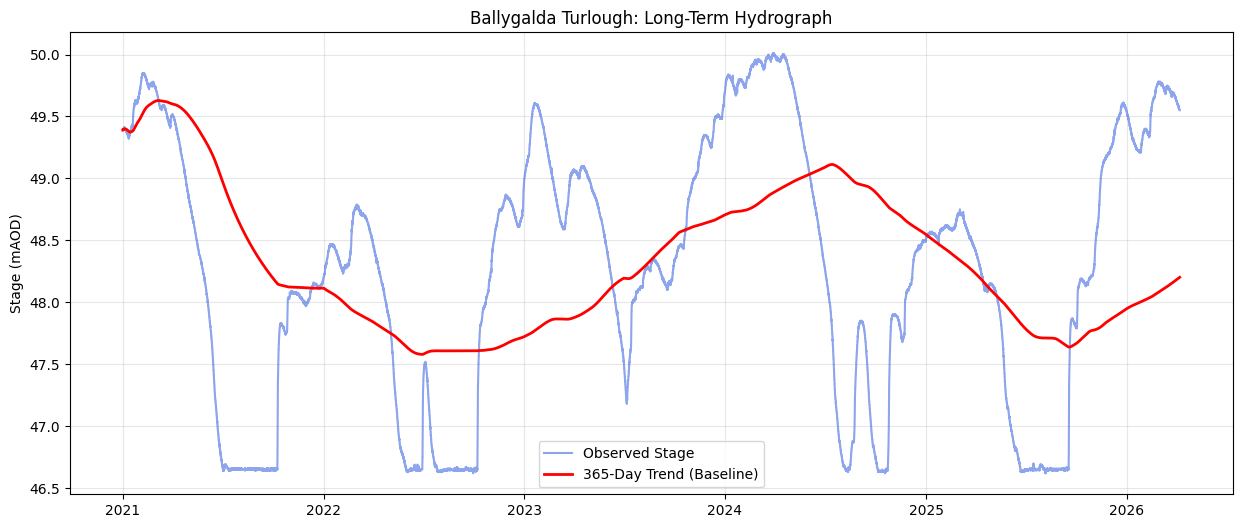

In [18]:
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Stage (mAOD)'], label='Observed Stage', color='royalblue', alpha=0.6)
plt.plot(df.index, df['365D_MA'], label='365-Day Trend (Baseline)', color='red', linewidth=2)
plt.title('Ballygalda Turlough: Long-Term Hydrograph')
plt.ylabel('Stage (mAOD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

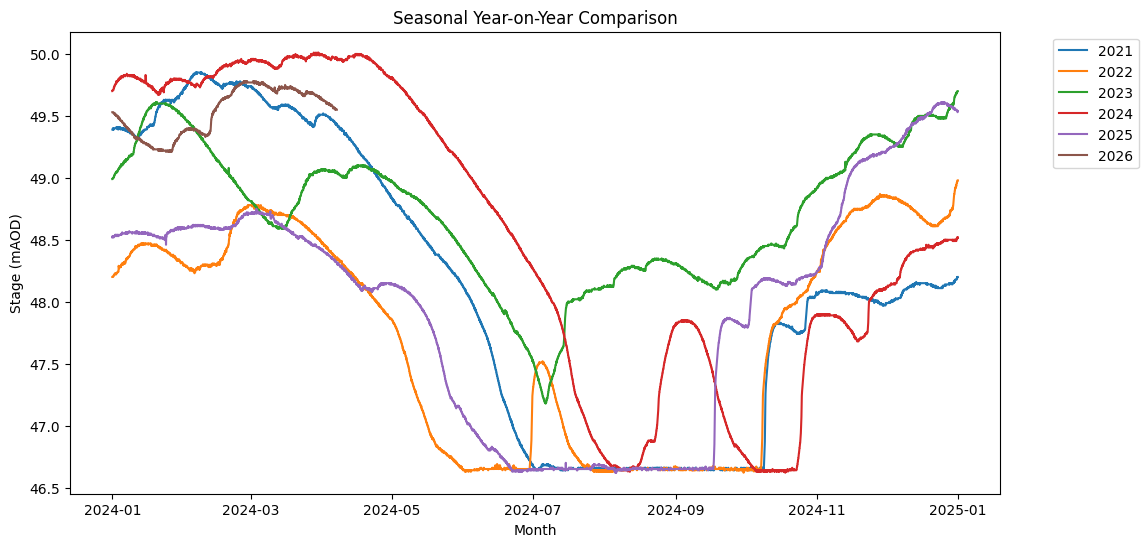

In [19]:
df['Year'] = df.index.year
df['DayOfYear'] = df.index.dayofyear
# Create a dummy date for plotting all years on one axis
df['DummyDate'] = pd.to_datetime('2024-' + df.index.strftime('%m-%d %H:%M:%S'), errors='coerce')

plt.figure(figsize=(12, 6))
for year in df['Year'].unique():
    year_data = df[df['Year'] == year]
    plt.plot(year_data['DummyDate'], year_data['Stage (mAOD)'], label=str(year))

plt.title('Seasonal Year-on-Year Comparison')
plt.xlabel('Month')
plt.ylabel('Stage (mAOD)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [20]:
# 8. Flood Peak Identification
# Find peaks with a minimum height and distance (e.g., 30 days apart)
peaks, _ = find_peaks(df['Stage (mAOD)'], distance=24*30, height=df['Stage (mAOD)'].mean())
flood_events = df.iloc[peaks]

In [21]:
# 9. Dry Period Identification
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df['is_dry'] = df['Stage (mAOD)'] <= dry_threshold

# Identify contiguous blocks of dry time
df['dry_group'] = (df['is_dry'] != df['is_dry'].shift()).cumsum()
dry_periods = df[df['is_dry']].groupby('dry_group').agg(
    start_date=('is_dry', lambda x: x.index.min()),
    end_date=('is_dry', lambda x: x.index.max()),
    duration=('is_dry', 'count') # Assuming hourly data, divide by 24 for days
)
dry_periods['duration_days'] = dry_periods['duration'] / 24

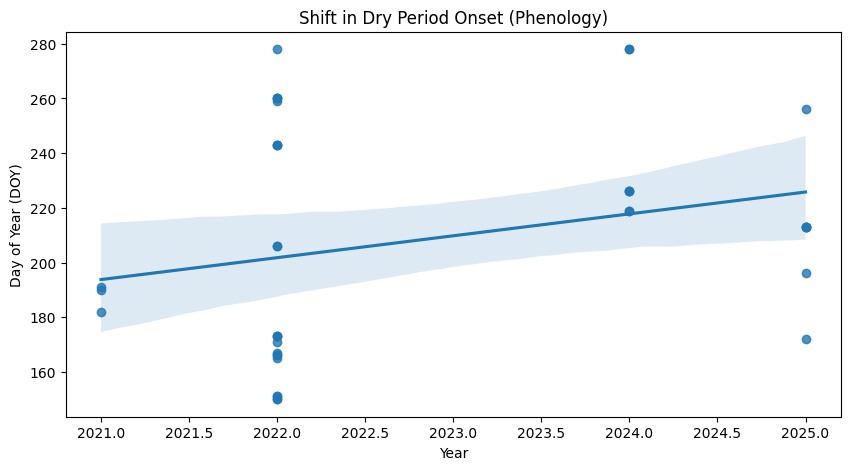

In [23]:
#10. Dry Period Ranking and Phenology
top_dry_spells = dry_periods.sort_values(by='duration_days', ascending=False)
dry_periods['Start_DOY'] = dry_periods['start_date'].dt.dayofyear
dry_periods['Year'] = dry_periods['start_date'].dt.year

# Plot Shift in Dry Period Start
plt.figure(figsize=(10, 5))
sns.regplot(data=dry_periods, x='Year', y='Start_DOY')
plt.title('Shift in Dry Period Onset (Phenology)')
plt.ylabel('Day of Year (DOY)')
plt.show()

In [25]:
# 11. Mann-Kendall Trend Test
# Resample to daily mean to reduce autocorrelation noise for the test
daily_mean = df['Stage (mAOD)'].resample('D').mean().dropna()

# Ensure pymannkendall is installed and imported
try:
    import pymannkendall as mk
except ModuleNotFoundError:
    print("pymannkendall not found. Installing...")
    !pip install pymannkendall
    import pymannkendall as mk # Re-import after installation

mk_result = mk.original_test(daily_mean)
print(f"\n--- Mann-Kendall Test ---")
print(f"Trend: {mk_result.trend}, P-value: {mk_result.p:.5f}, Sen's Slope: {mk_result.slope:.6f}")

pymannkendall not found. Installing...

--- Mann-Kendall Test ---
Trend: increasing, P-value: 0.00000, Sen's Slope: 0.000158


In [26]:
# 12. Return Period Analysis (Weibull)
# Using max dry duration per year
annual_max_dry = dry_periods.groupby('Year')['duration_days'].max().sort_values(ascending=False)
n = len(annual_max_dry)
ranks = np.arange(1, n + 1)
annual_max_dry_df = pd.DataFrame({'duration': annual_max_dry, 'rank': ranks})
annual_max_dry_df['ReturnPeriod'] = (n + 1) / annual_max_dry_df['rank']
print("\n--- Dry Spell Return Periods (Years) ---")
print(annual_max_dry_df[['duration', 'ReturnPeriod']])


--- Dry Spell Return Periods (Years) ---
       duration  ReturnPeriod
Year                         
2021  91.083333      5.000000
2025  42.958333      2.500000
2022  36.333333      1.666667
2024  19.166667      1.250000


In [27]:
# 13. Recession Constant (k) Calculation
# Select a specific declining limb (Example: a period in late spring)
# Replace these dates with a known falling limb in your data
start_recession = '2021-04-15'
end_recession = '2021-05-15'
limb = df.loc[start_recession:end_recession].copy()

if not limb.empty:
    limb['Time_Days'] = (limb.index - limb.index[0]).total_seconds() / (24*3600)
    limb['ln_stage'] = np.log(limb['Stage (mAOD)'])

    slope, intercept, r, p, std = linregress(limb['Time_Days'], limb['ln_stage'])
    k = abs(slope)
    print(f"\nRecession Constant (k) for {start_recession}: {k:.5f}")


Recession Constant (k) for 2021-04-15: 0.00051


Understanding the UnitsBecause your sampling interval is hourly, this $k$ value is likely hours$^{-1}$.To make it comparable to most published hydrological literature (which uses days$^{-1}$), multiply it by 24:$$k_{day} = 0.00051 \times 24 = 0.01224 \text{ days}^{-1}$$

In [29]:
#comparison
# Create year-specific dataframes
df_21 = df.loc['2021-01-01':'2021-12-31'].copy()
df_25 = df.loc['2025-01-01':'2025-12-31'].copy()

results = []

for year, data in [("2021", df_21), ("2025", df_25)]:
    # 1. Median Stage
    median_stage = data['Stage (mAOD)'].median()

    # 2. Dry Onset (Average Day of Year)
    # We define 'dry' as the minimum + 0.05m
    threshold = data['Stage (mAOD)'].min() + 0.05
    dry_days = data[data['Stage (mAOD)'] <= threshold]

    if not dry_days.empty:
        # Find the first time it hits the threshold in that year
        first_dry_date = dry_days.index.min()
        avg_doy = first_dry_date.dayofyear
        month_name = first_dry_date.strftime('%B')
    else:
        avg_doy, month_name = np.nan, "N/A"

    # 3. Max Dry Duration (Contiguous)
    data['is_dry'] = data['Stage (mAOD)'] <= threshold
    data['block'] = (data['is_dry'] != data['is_dry'].shift()).cumsum()
    dry_durations = data[data['is_dry']].groupby('block')['is_dry'].count() / 24 # hours to days
    max_dry = dry_durations.max() if not dry_durations.empty else 0

    results.append({
        "Year": year,
        "Median Stage": round(median_stage, 2),
        "Dry Onset (DOY)": avg_doy,
        "Month": month_name,
        "Max Dry Duration": round(max_dry, 1)
    })

# Display Results
comparison_df = pd.DataFrame(results)
print(comparison_df)

# Update these dates based on your 2025 hydrograph plot
start_25, end_25 = '2025-05-10', '2025-05-30'
limb_25 = df_25.loc[start_25:end_25].copy()

limb_25['Time_Hours'] = np.arange(len(limb_25))
slope_25, _, _, _, _ = linregress(limb_25['Time_Hours'], np.log(limb_25['Stage (mAOD)']))
k_25 = abs(slope_25)

print(f"2021 k: 0.00051") # From your previous result
print(f"2025 k: {k_25:.5f}")

   Year  Median Stage  Dry Onset (DOY) Month  Max Dry Duration
0  2021         48.07              181  June             100.7
1  2025         48.16              172  June              43.0
2021 k: 0.00051
2025 k: 0.00005


/tmp/ipykernel_17710/2470999424.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dry_blocks = df_2025[df_2025['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))


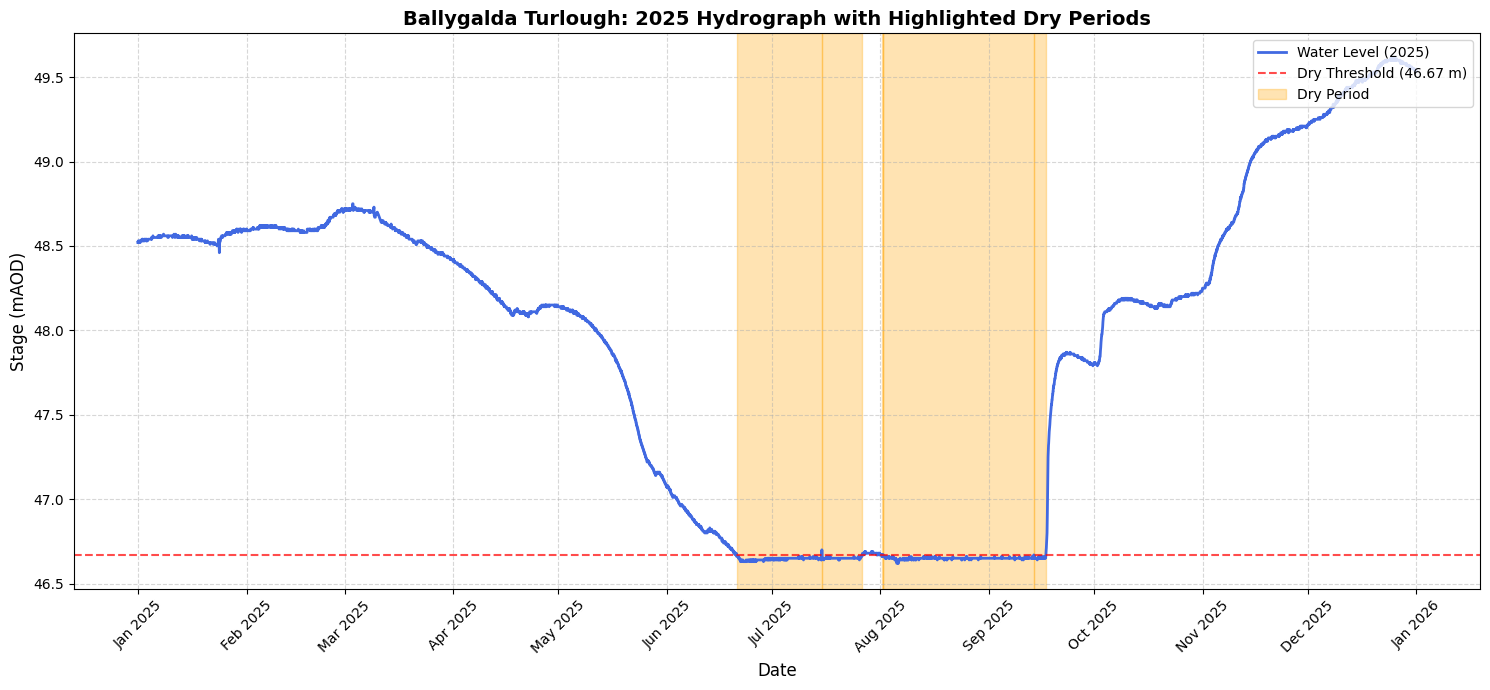

In [30]:
#2025 dry period
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Filter for the year 2025
df_2025 = df.loc['2025-01-01':'2025-12-31'].copy()

# 2. Define the dry threshold (based on entire dataset minimum)
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df_2025['is_dry'] = df_2025['Stage (mAOD)'] <= dry_threshold

# 3. Identify start and end dates for shading
# We group the 'is_dry' True blocks
df_2025['block'] = (df_2025['is_dry'] != df_2025['is_dry'].shift()).cumsum()
dry_blocks = df_2025[df_2025['is_dry']].groupby('block').apply(lambda x: (x.index.min(), x.index.max()))

# 4. Create the Plot
plt.figure(figsize=(15, 7))

# Plot the water level line
plt.plot(df_2025.index, df_2025['Stage (mAOD)'], color='royalblue', label='Water Level (2025)', linewidth=2)

# Plot the threshold line
plt.axhline(y=dry_threshold, color='red', linestyle='--', alpha=0.7, label=f'Dry Threshold ({dry_threshold:.2f} m)')

# Highlight the dry periods with shading
is_first_span = True
for start, end in dry_blocks:
    plt.axvspan(start, end, color='orange', alpha=0.3, label='Dry Period' if is_first_span else "")
    is_first_span = False

# Formatting the chart
plt.title('Ballygalda Turlough: 2025 Hydrograph with Highlighted Dry Periods', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stage (mAOD)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

# Improve x-axis date visibility
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

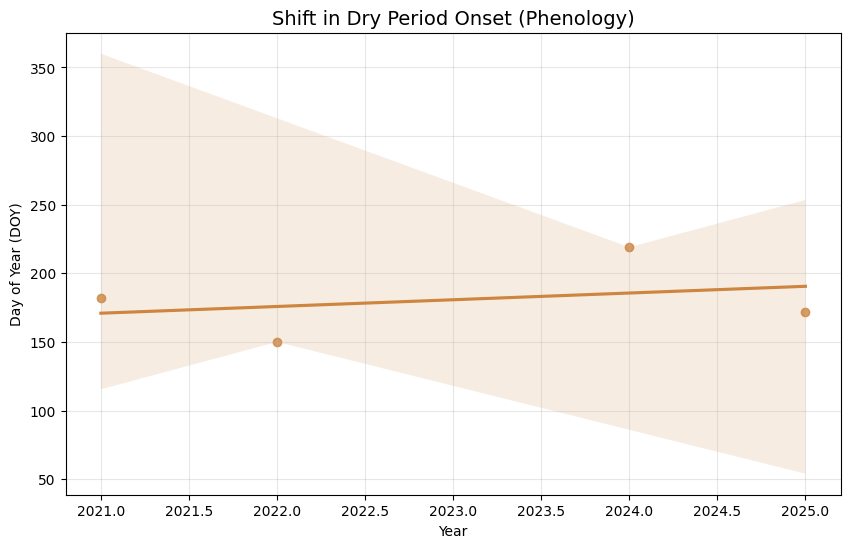

Phenology Shift: 4.90 days per year


In [31]:
#Analysis of Phenology (Dry Onset Timing)
import seaborn as sns

# 1. Define threshold and identify all dry periods in the full dataset
dry_threshold = df['Stage (mAOD)'].min() + 0.05
df['is_dry'] = df['Stage (mAOD)'] <= dry_threshold
df['dry_group'] = (df['is_dry'] != df['is_dry'].shift()).cumsum()

# 2. Extract start date and duration for every dry spell
all_dry_spells = df[df['is_dry']].groupby('dry_group').agg(
    start_date=('is_dry', lambda x: x.index.min()),
    duration_days=('is_dry', lambda x: len(x) / 24)
).copy()

all_dry_spells['Year'] = all_dry_spells['start_date'].dt.year
all_dry_spells['DOY'] = all_dry_spells['start_date'].dt.dayofyear

# 3. Find the FIRST dry onset per year
annual_first_dry = all_dry_spells.groupby('Year')['DOY'].min().reset_index()

# 4. Plot the Phenology Shift
plt.figure(figsize=(10, 6))
sns.regplot(data=annual_first_dry, x='Year', y='DOY', color='peru', marker='o')
plt.title('Shift in Dry Period Onset (Phenology)', fontsize=14)
plt.ylabel('Day of Year (DOY)')
plt.grid(True, alpha=0.3)
plt.show()

# Print the shift magnitude
slope, _, _, _, _ = linregress(annual_first_dry['Year'], annual_first_dry['DOY'])
print(f"Phenology Shift: {slope:.2f} days per year")

In [32]:
# 1. Get the MAXIMUM dry duration for each year
annual_max_dry = all_dry_spells.groupby('Year')['duration_days'].max().sort_values(ascending=False).reset_index()

# 2. Apply Weibull Formula: T = (n + 1) / m
n = len(annual_max_dry)
annual_max_dry['Rank'] = range(1, n + 1)
annual_max_dry['Return_Period_T'] = (n + 1) / annual_max_dry['Rank']
annual_max_dry['Exceedance_Probability_P'] = 1 / annual_max_dry['Return_Period_T']

print("--- Return Period Table (Weibull) ---")
print(annual_max_dry[['Year', 'duration_days', 'Return_Period_T']])

# 3. Frequency Shift Logic (Comparing 50-day events)
def check_frequency(duration_threshold):
    # Filter for spells exceeding threshold
    freq = annual_max_dry[annual_max_dry['duration_days'] >= duration_threshold]
    if not freq.empty:
        highest_rank = freq['Rank'].max()
        return_period = (n + 1) / highest_rank
        print(f"\nA dry spell > {duration_threshold} days currently has a {return_period:.1f}-year return period.")
    else:
        print(f"\nNo dry spells > {duration_threshold} days observed in this record.")

check_frequency(50)

--- Return Period Table (Weibull) ---
   Year  duration_days  Return_Period_T
0  2021      91.083333         5.000000
1  2025      42.958333         2.500000
2  2022      36.333333         1.666667
3  2024      19.166667         1.250000

A dry spell > 50 days currently has a 5.0-year return period.


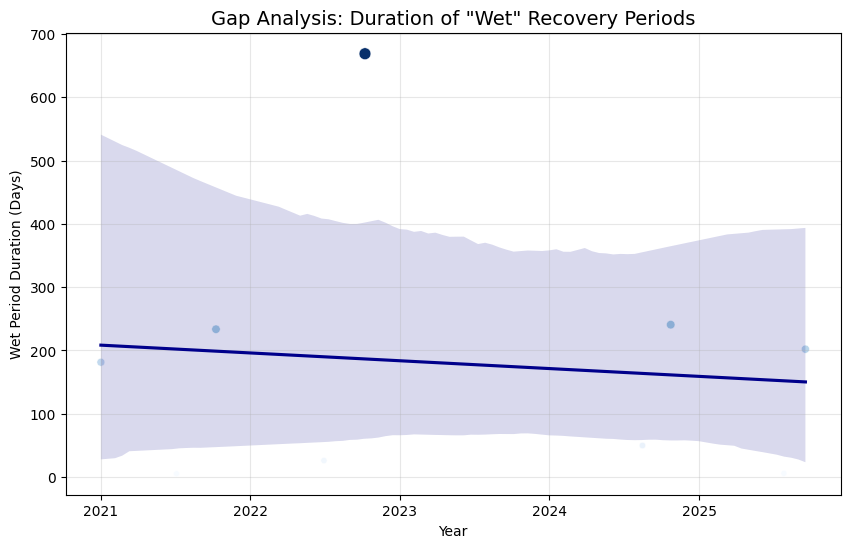

Average Recovery (Wet) Time in 2021: 140.0 days
Average Recovery (Wet) Time in 2025: 103.9 days


In [33]:
#recovery failure
# 1. Identify the 'Wet' periods (The gaps between dry spells)
# We use the 'is_dry' logic from the previous step
df['is_wet'] = ~df['is_dry']

# 2. Identify contiguous blocks of wet time
df['wet_group'] = (df['is_wet'] != df['is_wet'].shift()).cumsum()

# 3. Calculate duration for every wet period
wet_periods = df[df['is_wet']].groupby('wet_group').agg(
    start_date=('is_wet', lambda x: x.index.min()),
    end_date=('is_wet', lambda x: x.index.max()),
    duration_days=('is_wet', lambda x: len(x) / 24)
).copy()

# 4. Filter out very short 'noise' (e.g., wet periods < 1 day)
# and ignore the very first/last periods which might be cut off by the dataset limits
wet_periods = wet_periods[wet_periods['duration_days'] > 1]
wet_periods['Year'] = wet_periods['start_date'].dt.year

# 5. Plot the Trend in Recovery Time
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wet_periods, x='start_date', y='duration_days', size='duration_days', hue='duration_days', palette='Blues', legend=None)
sns.regplot(data=wet_periods, x=mdates.date2num(wet_periods['start_date']), y='duration_days', scatter=False, color='darkblue')

plt.title('Gap Analysis: Duration of "Wet" Recovery Periods', fontsize=14)
plt.ylabel('Wet Period Duration (Days)')
plt.xlabel('Year')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Statistical Comparison: 2021 vs 2025
avg_wet_21 = wet_periods[wet_periods['Year'] == 2021]['duration_days'].mean()
avg_wet_25 = wet_periods[wet_periods['Year'] == 2025]['duration_days'].mean()

print(f"Average Recovery (Wet) Time in 2021: {avg_wet_21:.1f} days")
print(f"Average Recovery (Wet) Time in 2025: {avg_wet_25:.1f} days")